Для отображения SVG и интерактивных плотов необходимо установить:

pip install "drawsvg~=2.0"

pip install plotly

In [1]:
import sys

import plotly.graph_objects as go
from matplotlib import pyplot as plt
from plotly.subplots import make_subplots

sys.path.append("..")
from kandinsky.datasets.mask_bank import (
    create_mask_bank,
    draw_full_mask,
    draw_reordered_full_mask,
    generate_random_sequence,
    reorder_sequence,
)

from kandinsky.datasets.mask_bank2 import create_mask_bank as create_mask_bank2

In [2]:
seq, seq_types = generate_random_sequence(204, (10, 15), (12, 19))
print("Длина сгенерированной последовательности", sum([sum(s) for s in seq]))

Длина сгенерированной последовательности 199


In [3]:
reorder_seq, mat1, mat2 = reorder_sequence(seq, seq_types)

fig = make_subplots(cols=2, rows=1, subplot_titles=["Original", "Reordered"])
fig.add_trace(go.Heatmap(z=mat1, showscale=False), col=1, row=1)
fig.add_trace(go.Heatmap(z=mat2, showscale=False), col=2, row=1)
fig.update_yaxes(autorange="reversed")
fig.update_layout(width=1200, height=600)
fig.show()

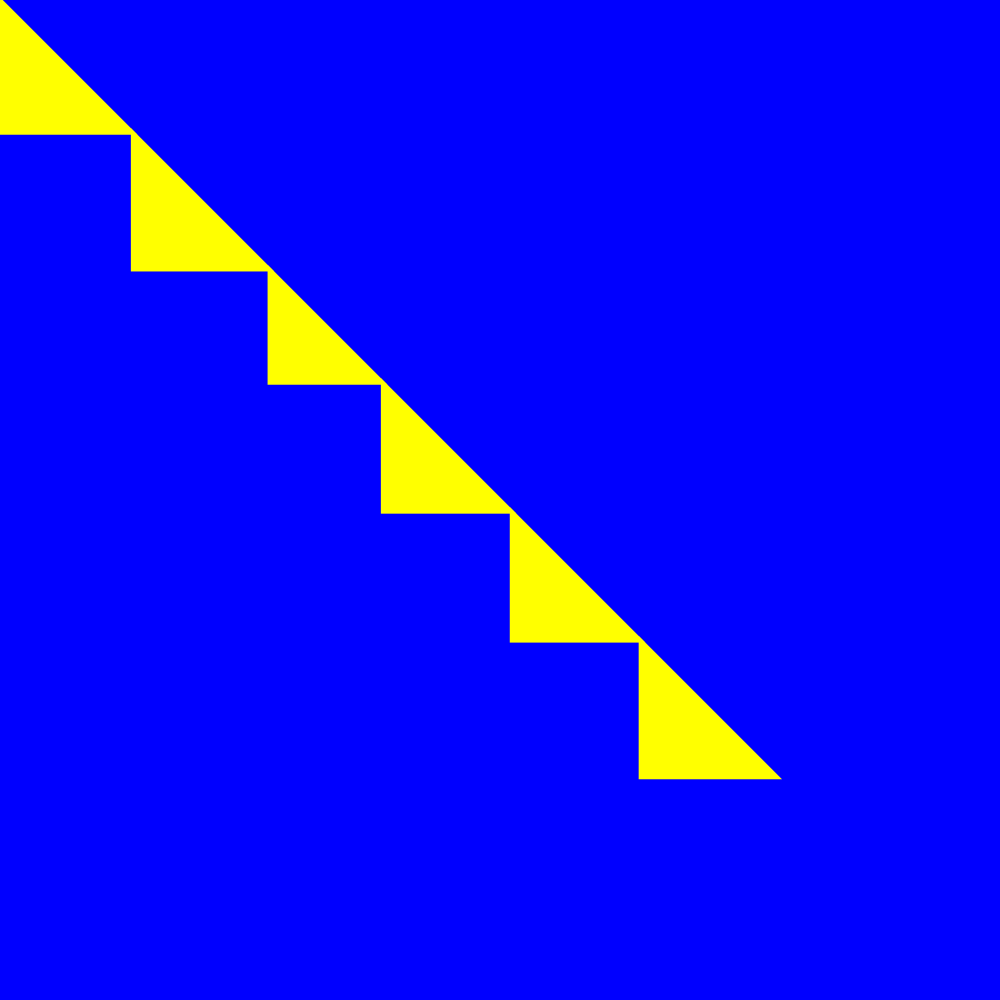

In [4]:
img = draw_full_mask(seq, seq_types)
img.set_render_size(w=1000)
img

In [5]:
print(reorder_seq)

[33, 1, 34, 1, 29, 32, 1, 32, 1, 34, 1, 0, 0, 0, 0, 0]


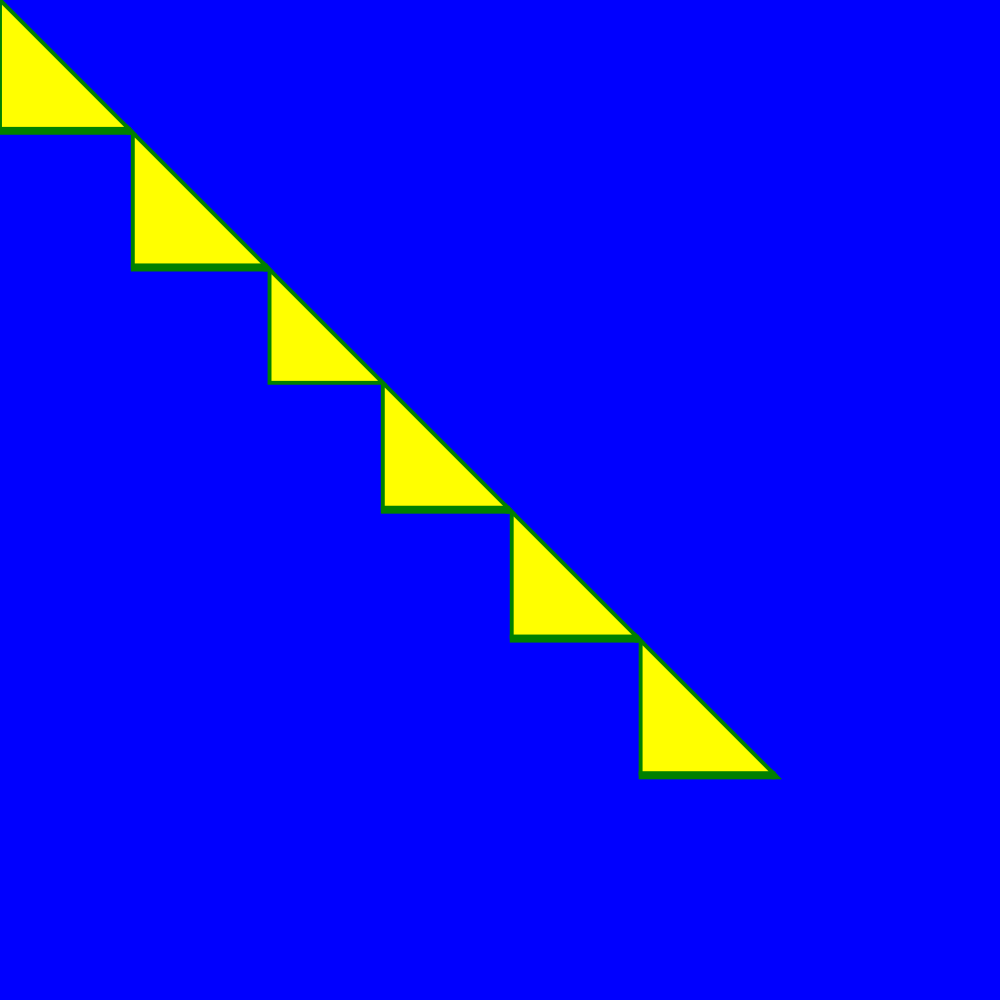

In [6]:
img = draw_reordered_full_mask(reorder_seq, mat2)
img.set_render_size(w=1000)
img

In [7]:
block_mask, unique_blocks = create_mask_bank(reorder_seq, mat2)
block_mask2, unique_blocks2 = create_mask_bank2(reorder_seq, mat2)

(0, (1, 0))
((1, 0), 0)
(0, 0)
(0, (1, 0))
((1, 0), 0)
(0, 0)
(0, 0)
(1, (1, 1))
(1, 0)
(1, 1)
((2, 1), 1)
(1, 1)
(1, (2, 1))
((2, 1), 1)
(1, 1)
(1, 1)
(2, (2, 2))
(2, 1)
(2, 2)
((3, 2), 2)
(2, 2)
(2, (3, 2))
((3, 2), 2)
(2, 2)
(2, (3, 2))
((3, 2), 2)
(2, 2)
(2, (3, 2))
((3, 2), 2)
(2, 2)
(2, (4, 3))
((3, 2), 3)
(2, 3)
(2, 2)
(3, (3, 3))
(3, 2)
(3, 3)
((4, 3), 3)
(3, 3)
(3, (4, 3))
((4, 3), 3)
(3, 3)
(3, (4, 3))
((4, 3), 3)
(3, 3)
((4, 3), 0)
(3, 0)
(3, (4, 3))
((4, 3), 3)
(3, 3)
((4, 3), 1)
((4, 3), 2)
(3, 1)
(3, 2)
(3, (4, 3))
((4, 3), 3)
(3, 3)
((4, 3), 2)
(3, 2)
(3, (4, 3))
((4, 3), 3)
(3, 3)
(3, (3, 3))
((4, 3), 2)
((4, 3), 3)
(3, 2)
(3, 3)
(3, (4, 3))
((4, 3), 3)
(3, 3)


In [8]:
print((block_mask2 - block_mask).abs().sum())
print([(unique_blocks2[i] - unique_blocks[i]).abs().sum() for i in range(len(unique_blocks))])

tensor(58)
[tensor(0), tensor(0), tensor(0), tensor(122332), tensor(8042), tensor(145), tensor(23014), tensor(246131), tensor(1724), tensor(7290)]


In [9]:
fig = go.Figure()
fig.add_trace(go.Heatmap(z=block_mask[:2048, :2048], showscale=False))
fig.update_yaxes(autorange="reversed")
fig.update_layout(width=1000, height=1000)
fig.show()

In [10]:
fig = go.Figure()
fig.add_trace(go.Heatmap(z=block_mask2[:2048, :2048], showscale=False))
fig.update_yaxes(autorange="reversed")
fig.update_layout(width=1000, height=1000)
fig.show()

In [11]:
len(unique_blocks)

10

In [12]:
len(unique_blocks2)

29

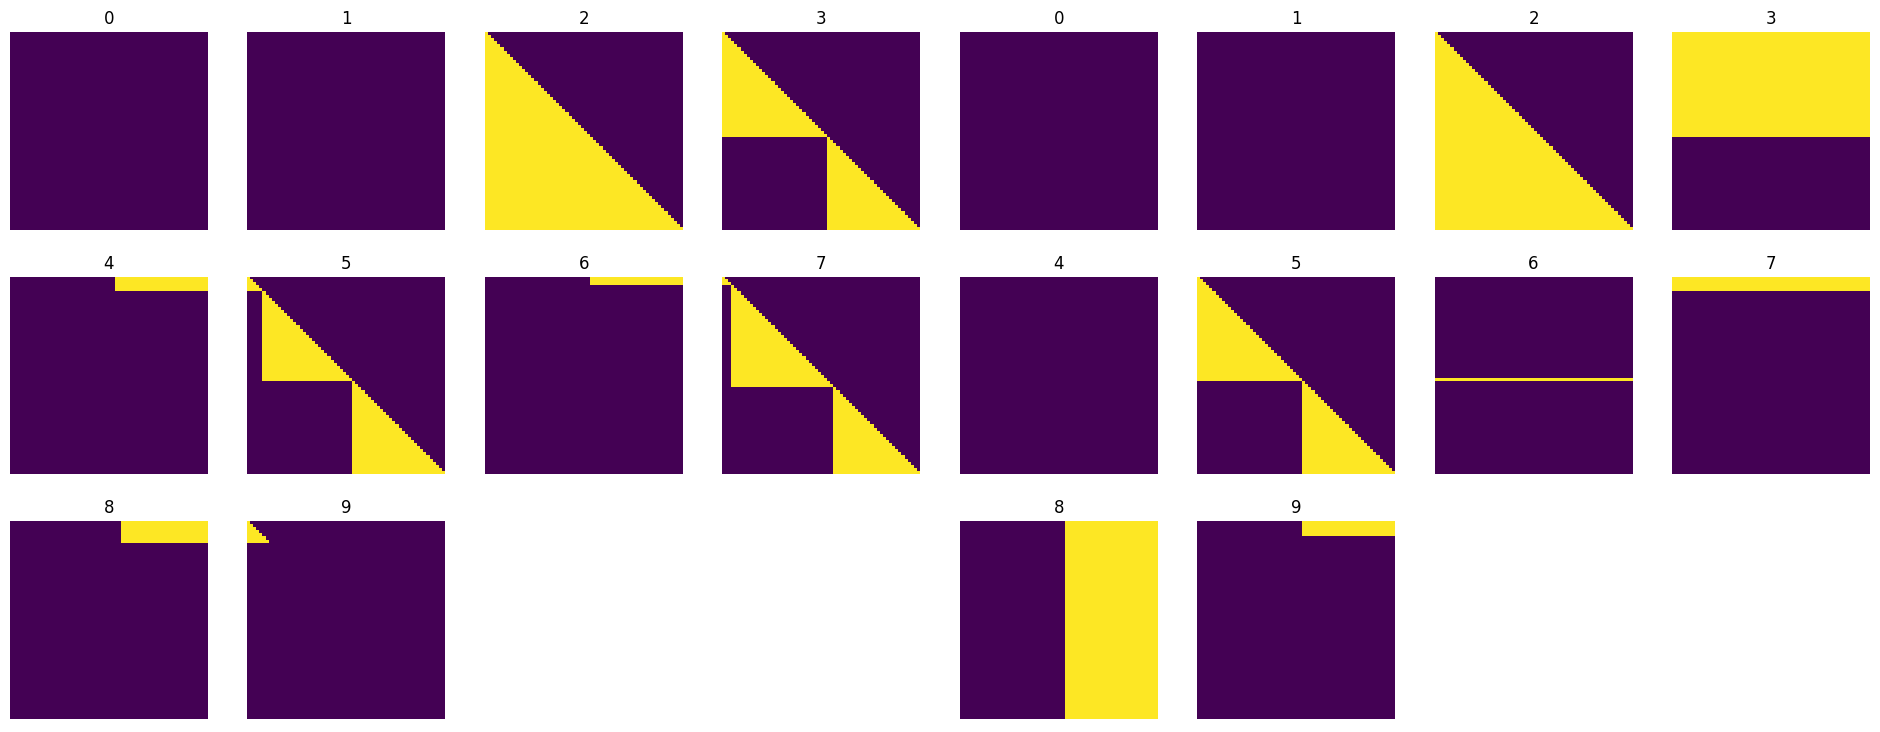

In [13]:
W = 4
H = len(unique_blocks) // W + 1
fig, ax = plt.subplots(H, 2 * W, figsize=(W * 6, H * 3))
for i in range(H):
    for j in range(W):
        if W * i + j < len(unique_blocks):
            ax[i, j].imshow(unique_blocks[W * i + j])
            ax[i, j].title.set_text(str(W * i + j))
            ax[i, j + W].imshow(unique_blocks2[W * i + j])
            ax[i, j + W].title.set_text(str(W * i + j))
        ax[i, j].axis("off")
        ax[i, j + W].axis("off")
fig.show()

In [14]:
unique_blocks2[12][:, 0]

tensor([2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.uint8)

In [15]:
unique_blocks[13][:, 0]

IndexError: list index out of range

In [ ]:
(unique_blocks2[7] - unique_blocks[5]).sum()

tensor(219975)